[20.42254702 13.46190482 19.03248488  7.77096104  1.89325711]
124.0
[18.38866084  5.85152404 10.62953115  6.38991907 10.86064282]
124.00000000000001
[19.49988819 23.30204405 24.36345616 20.67348648 24.76343175]
124.0
[20.42254702 13.46190482 19.03248488  7.77096104  1.89325711 11.37472459
 15.70014754  3.05856555 19.0533745  11.68088675]
124.00000000000003
[19.49988819 23.30204405 24.36345616 20.67348648 24.76343175  5.0447317
 14.38678293  3.55997028  9.12673436 18.31735886]
124.00000000000003
[12.96713058 14.49512822 18.16550109  9.87173947 21.67202906 22.74111054
  5.04859543  2.28179845  6.12923197  3.14288602]
124.00000000000003
[20.42254702 13.46190482 19.03248488  7.77096104  1.89325711 11.37472459
 15.70014754  3.05856555 19.0533745  11.68088675 18.38866084  5.85152404
 10.62953115  6.38991907 10.86064282]
123.99999999999999
[19.10846712 17.81255803  4.22991559 20.99091275  8.14358916  3.6933586
  5.42549593  4.21771992  4.49710879 17.33477469 12.96713058 14.49512822
 18.165501

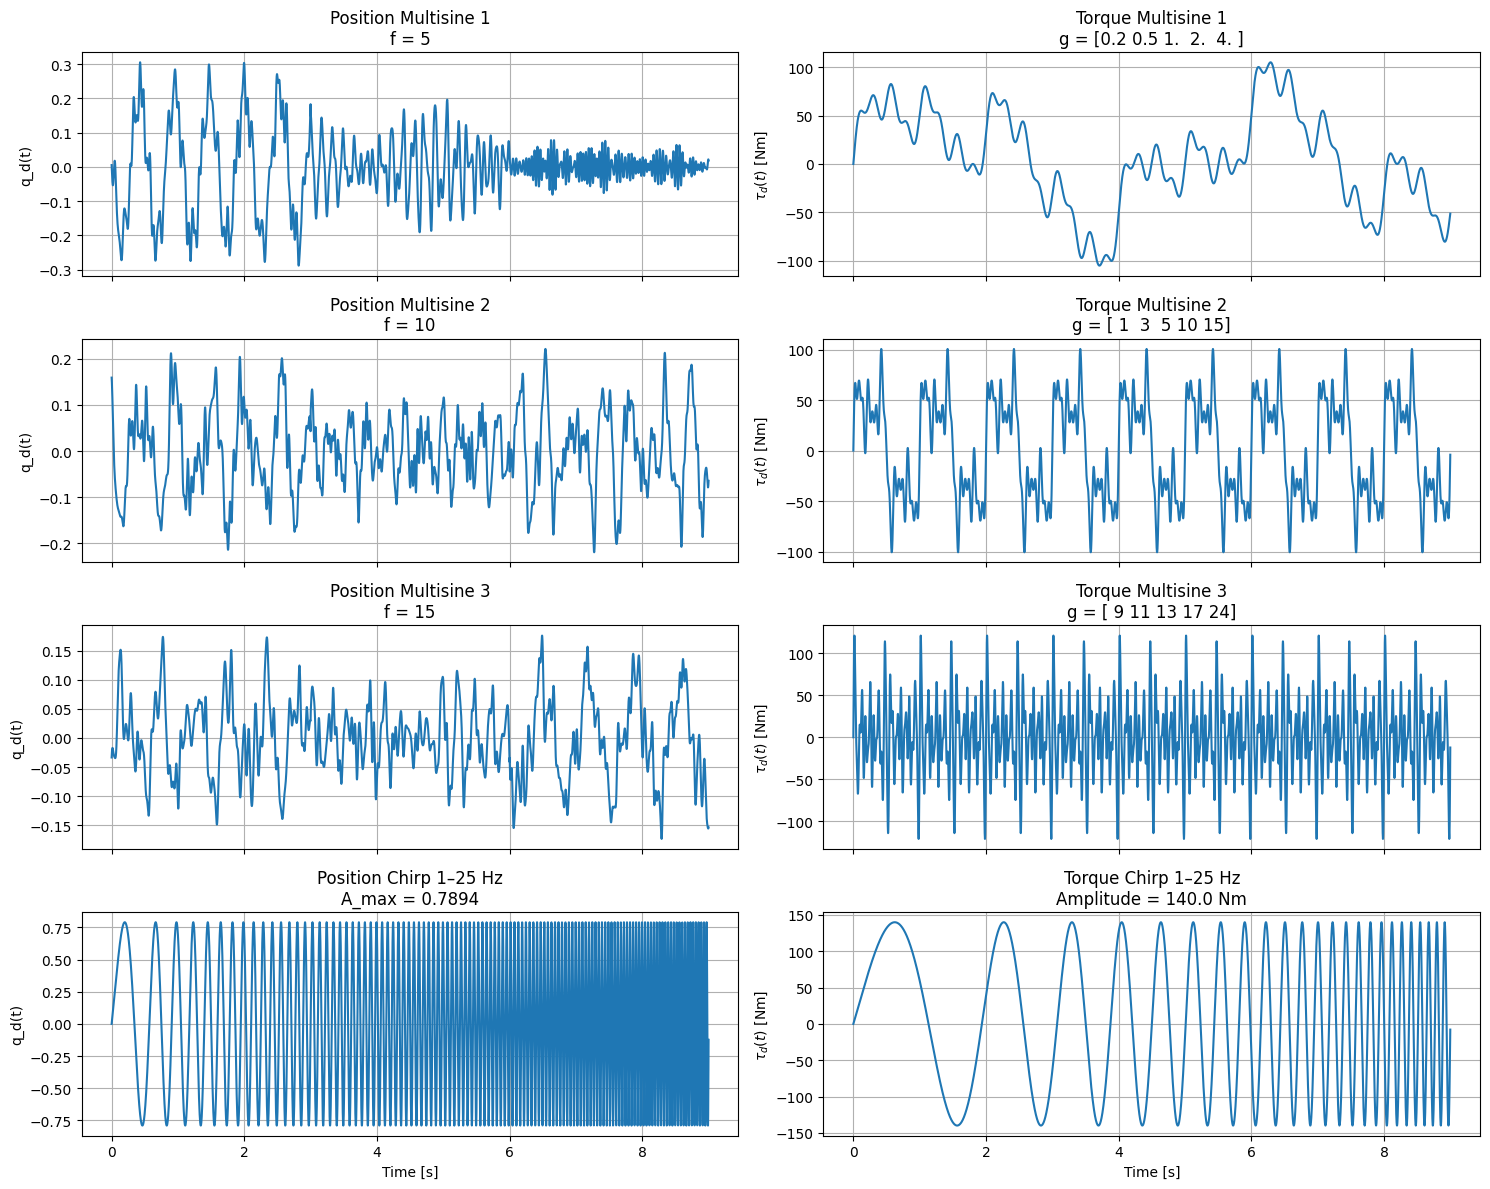


Position Multisine 1
Frequencies: [0.5 1.  2.  4.  8. ]
Amplitudes A_k = [39.47042589  9.86760647  3.28920216  1.23345081  0.49338032]

Position Multisine 2
Frequencies: [ 1  3  5 10 15]
Amplitudes A_k = [19.73521294  3.28920216  1.31568086  0.49338032  0.26313617]

Position Multisine 3
Frequencies: [11 13 15 17 24]
Amplitudes A_k = [1.79411027 0.75904665 0.43856029 0.29022372 0.16446011]

Torque Multisine 1
Frequencies: [0.2 0.5 1.  2.  4. ]
Amplitudes B_m = [62.60990337 39.59797975 28.         19.79898987 14.        ]

Torque Multisine 2
Frequencies: [ 1  3  5 10 15]
Amplitudes B_m = [28.         16.16580754 12.52198067  8.85437745  7.22956891]

Torque Multisine 3
Frequencies: [ 9 11 13 17 24]
Amplitudes B_m = [9.33333333 8.44231765 7.76580275 6.7909975  5.71547607]

Position chirp amplitude limit from velocity bound: 0.789409
Torque chirp amplitude: 140.00 Nm


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# General settings
# --------------------------------------------------
fs = 1000
T = 9
T2 = 30
t = np.arange(0, T, 1/fs)

v_max = 124.0         # max velocity for position signals
tau_max = 140.0       # max torque for torque multisine
tau_chirp_amp = 140.0 # amplitude for torque chirp

# --------------------------------------------------
# Position frequency sets
# --------------------------------------------------
freqs1 = np.array([0.5, 1, 2, 4,8])
freqs4 = np.arange(1, 25, 1)
freqs4 = np.array ([1, 3, 5, 10, 15])
freqs5 = np.array([11, 13, 15, 17, 24])

n_freqs1 = 5
n_freqs2 = 10
n_freqs3 = 15

pos_freq_sets = [freqs1, freqs4, freqs5]
pos_n_freqs_sets = [n_freqs1, n_freqs2, n_freqs3]

# --------------------------------------------------
# Torque multisine frequency sets
# I match three torque sets to the three position rows
# Row 1 uses your explicit low-frequency torque set
# Rows 2 and 3 are chosen to mirror broader bands
# --------------------------------------------------
g1 = np.array([0.2, 0.5, 1, 2, 4])
g2 = np.array([1, 3, 5, 10, 15])
g3 = np.array([9,11,13, 17, 24])

torque_freq_sets = [g1, g2, g3]

# --------------------------------------------------
# Helper functions
# --------------------------------------------------
def PosMultisine(freqs, t, v_max,use_schroeder=False, seed=None):
    freqs = np.array(freqs, dtype=float)
    k = np.arange(1, len(freqs) + 1)

    # Your chosen amplitude law
    A = v_max / (2 * np.pi * freqs * len(freqs))

    if use_schroeder:
        N = len(freqs)
        phases = np.pi * k * (k - 1) / N
    else:
        phases = np.zeros(len(freqs))

    x = np.sum(
        A[:, None] * np.sin(2 * np.pi * freqs[:, None] * t + phases[:, None]),
        axis=0
    )
    return x, A, freqs, phases

def RandPosMultisine(n_freqs, t, v_max, use_schroeder=False, seed=None):
    rng = np.random.default_rng(seed)

    fs = 1 / (t[1] - t[0])
    segment_length=3.0
    samples_per_segment = int(segment_length * fs)

    x = np.zeros_like(t)

    n_segments = int(np.ceil(len(t) / samples_per_segment))

    for s in range(n_segments):
        start = s * samples_per_segment
        end = min((s + 1) * samples_per_segment, len(t))

        t_seg = t[start:end] - t[start]  # reset time to 0 per segment

        # --- new random frequencies per segment ---
        freqs = rng.uniform(0.5, 25, n_freqs)
        k = np.arange(1, len(freqs) + 1)

        # amplitude law
        A = v_max / (60 * freqs * n_freqs)

        # phases
        if use_schroeder:
            N = len(freqs)
            phases = np.pi * k * (k - 1) / N
        else:
            phases = rng.uniform(0,2*np.pi,n_freqs)

        # generate segment signal
        x_seg = np.sum(
            A[:, None] * np.sin(2 * np.pi * freqs[:, None] * t_seg + phases[:, None]),
            axis=0
        )

        x[start:end] = x_seg
        print(freqs)
        print(sum(A*freqs*60))
    return x, _, n_freqs, _

def TorqueMultisine(freqs, t, tau_max, random_phase=False, seed=0):
    freqs = np.array(freqs, dtype=float)
    # Shape the amplitudes as 1/sqrt(f)
    B_shape = 1 / np.sqrt(freqs)

    # Normalize so sum(B) = tau_max
    B = tau_max * B_shape / np.sum(B_shape)

    if random_phase:
        rng = np.random.default_rng(seed)
        phases = rng.uniform(0, 2 * np.pi, len(freqs))
    else:
        phases = np.zeros(len(freqs))

    tau = np.sum(
        B[:, None] * np.sin(2 * np.pi * freqs[:, None] * t),
        axis=0
    )
    return tau, B, phases

def PosChirp(t, T, v_max, f_min=1.0, f_max=25.0):
    # A_max from velocity bound: A <= v_max / (2*pi*f_max)
    A = v_max / (2 * np.pi * f_max)

    phi = 2 * np.pi * (f_min * t + ((f_max - f_min) / (2 * T)) * t**2)
    x = A * np.sin(phi)
    return x, A

def TorqueChirp(t, T, amp=140.0, f_min=1.0, f_max=25.0, phi0=0.0):
    # Linear chirp:
    # tau_d(t) = amp * sin(2*pi*(f_min*t + ((f_max-f_min)/(2T))*t^2) + phi0)
    phi = 2 * np.pi * (f_min * t + ((f_max - f_min) / (2 * T)) * t**2) + phi0
    tau = amp * np.sin(phi)
    return tau

def maxonTorqueChirp(t, T, amp=140.0, f_min=1.0, f_max=25.0, phi0=0.0):
    
    ms_to_s = 0.001
    mNm_to_Nm = 0.001
    
    tau_0 = 0.0 # Nm
    amp = amp # Nm

    t0 = 0.0 # Ramp up time ms

    t_ms= t/ms_to_s # ms
    T_ms = T/ms_to_s # ms
    
    f_scale = f_max/f_min
    f0Inst = f_min*T/np.log(f_scale)
    f1Inst = f_scale*f0Inst
    InstFreqCorrFactor = np.log(f_scale)*1000/(T)
    
    if t0 > 0.0:
        ChirpTime = T + t0  #duration of chirp
        t = np.arange(0, ChirpTime, 1/fs) #updated time vector
    
    amps = np.ones(len(t))*amp #define ref amplitude
    amps[t < t0] *= (t[t < t0]/t0) #ramp up ref amplitude
    
    freq = f0Inst * (np.power(f_scale, t/T)-1)
    tau =  tau_0 + amps * np.sin(2.0*np.pi*freq + phi0)

    return tau

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(4, 2, figsize=(15, 12), sharex=True)

# --- Rows 1 to 3: multisines ---
for i in range(3):
    # Position multisine
    x_pos, A_pos, freq_pos, _ = RandPosMultisine(pos_n_freqs_sets[i], t, v_max, use_schroeder=False, seed=512345)
    axes[i, 0].plot(t, x_pos)
    axes[i, 0].set_title(f"Position Multisine {i+1}\nf = {freq_pos}")
    axes[i, 0].set_ylabel("q_d(t)")
    axes[i, 0].grid(True)

    # Torque multisine
    tau_ms, B_tau, _ = TorqueMultisine(torque_freq_sets[i], t, tau_max, random_phase=True, seed=42+i)
    axes[i, 1].plot(t, tau_ms)
    axes[i, 1].set_title(f"Torque Multisine {i+1}\ng = {torque_freq_sets[i]}")
    axes[i, 1].set_ylabel(r"$\tau_d(t)$ [Nm]")
    axes[i, 1].grid(True)

# --- Row 4: chirps ---
x_chirp, A_chirp = PosChirp(t, T, v_max, f_min=1.0, f_max=25.0)
tau_ch = maxonTorqueChirp(t,T, amp=tau_chirp_amp, f_min=1.0, f_max=25.0, phi0=0.0)

axes[3, 0].plot(t, x_chirp)
axes[3, 0].set_title(f"Position Chirp 1–25 Hz\nA_max = {A_chirp:.4f}")
axes[3, 0].set_ylabel("q_d(t)")
axes[3, 0].set_xlabel("Time [s]")
axes[3, 0].grid(True)

axes[3, 1].plot(t, tau_ch)
axes[3, 1].set_title(f"Torque Chirp 1–25 Hz\nAmplitude = {tau_chirp_amp:.1f} Nm")
axes[3, 1].set_ylabel(r"$\tau_d(t)$ [Nm]")
axes[3, 1].set_xlabel("Time [s]")
axes[3, 1].grid(True)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Print amplitudes
# --------------------------------------------------
for i, freqs in enumerate(pos_freq_sets):
    k = np.arange(1, len(freqs) + 1)
    A = v_max / (2 * np.pi * freqs * k)
    print(f"\nPosition Multisine {i+1}")
    print("Frequencies:", freqs)
    print("Amplitudes A_k =", A)

for i, freqs in enumerate(torque_freq_sets):
    B = tau_max / (5 * np.sqrt(freqs))
    print(f"\nTorque Multisine {i+1}")
    print("Frequencies:", freqs)
    print("Amplitudes B_m =", B)

print(f"\nPosition chirp amplitude limit from velocity bound: {A_chirp:.6f}")
print(f"Torque chirp amplitude: {tau_chirp_amp:.2f} Nm")